# **Tabular Fake News Detection**

## **Background**

We are in an election year and news accuracy will be an increaing problem. The proliferation of online content and social media platforms has given rise to  the spread of fake news. Fake news refers to misleading or fabricated information presented as genuine news, often with the intention to deceive or manipulate public opinion. In many cases there are nation states involved. Detecting fake news has become a significant challenge, as it requires distinguishing between credible information and deceptive content. 

## **Problem Description**

Our charge is to develop several Machine Learning models capable of detecting fake news articles, with the end goal of developing the best possible model.

The data that we will use to do this from a tabular dataset containing metadata-level information about each article such as the word count, average word length, number of sentences and number of unique words. This dataset will contain both real and fake news articles, and the Machine Learning model's task is to correctly segregate the fake news articles from real.

You need to augment the EDA in this notebook - this would include better labels on the charts as well as addtional EDA functionality. You also need to develop 4 additional models.  There should be a summary table at the end of the notebook along with some graphical presentation of results.

## **Reading the Dataset**

In [1]:
# Importing the required libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Library for data manipulation and analysis
import pandas as pd
import numpy as np

# Library for statistical data visualization
import seaborn as sns
# Library for creating visualizations
import matplotlib.pyplot as plt

# Importing the RandomForestClassifier algorithm
from sklearn.ensemble import RandomForestClassifier

# Library for splitting data into training and testing sets
from sklearn.model_selection import train_test_split

 # Library for evaluating model accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score , f1_score, confusion_matrix

C:\Users\codyd\AppData\Local\Temp\ipykernel_6396\2578141520.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
#Loading the dataset
df = pd.read_csv("Tabular_data_1.3.csv")

In [3]:
#Let us see the first 10 rows of the dataset
df.head(10)

,ID,Word_Count,Number_of_Sentence,Unique_Words,Average_Word_Length,Label
0,1606,10,4,24,6.176750,1
1,3718,10,8,25,5.826770,1
2,2634,10,7,18,4.619040,1
3,5560,10,6,18,4.961424,1
4,7494,10,4,21,4.114324,1
5,3159,39,5,16,4.582874,1
6,7232,11,4,21,5.756046,1
7,7509,11,5,21,4.502690,1
8,1509,11,6,24,3.943672,1
9,1657,11,8,19,5.419068,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   4500 non-null   int64  
 1   Word_Count           4500 non-null   int64  
 2   Number_of_Sentence   4500 non-null   int64  
 3   Unique_Words         4500 non-null   int64  
 4   Average_Word_Length  4500 non-null   float64
 5   Label                4500 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 211.1 KB


- Most columns are of the int64 data type, which is typically used for integer values. However, the "Average_Word_Length" column is of the float64 data type, suggesting that it contains decimal values.

- The "Non-Null Count" indicates that all 6 columns have 4500 non-null entries, meaning there are no missing values.

## **Summary Statistics**

In [5]:
df.describe()

,ID,Word_Count,Number_of_Sentence,Unique_Words,Average_Word_Length,Label
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,5469.140000,53.934000,8.934667,24.943333,4.968105,0.329556
std,2599.193059,24.872743,3.407847,11.540708,1.152394,0.470104
min,1002.000000,10.000000,4.000000,5.000000,3.000385,0.000000
25%,3228.750000,35.000000,6.000000,17.000000,3.980553,0.000000
50%,5449.500000,52.000000,9.000000,22.000000,4.906200,0.000000
75%,7706.750000,75.000000,12.000000,33.000000,5.996111,1.000000
max,9999.000000,100.000000,15.000000,50.000000,6.999799,1.000000


- **The mean of "Word_Count" is 53.934, and "Number_of_sentence" is 8.93.**

- The median of "Unique_Words" is 22, indicating that half of the data points have unique word counts below this value.

- The maximum Number_of_sentence is 15.

- The maximum count of unique words in a sentence is 50. This means that there is a sentence with a vocabulary of 50 distinct words.



## **Exploratory Data Analysis (EDA)**

In [6]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()

In [7]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    data[feature].describe()
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

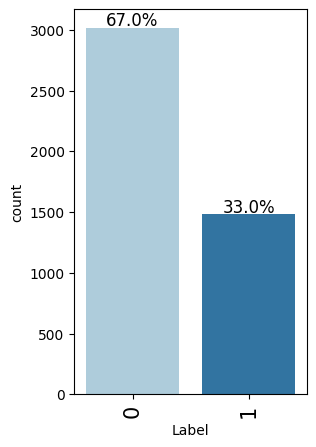

In [8]:
# Plotting the distribution of labels
labeled_barplot(df, 'Label', perc=True)

**The dataset contains 3017 instances of Real News (Label 0) and 1483 instances of Fake News (Label 1).** This indicates a **class imbalance**, where the number of real news instances is significantly larger than the number of fake news instances.

This could potentially impact the performance of a Machine Learning model, as it might be biased towards classifying news as real due to the larger number of instances.

### Word Count

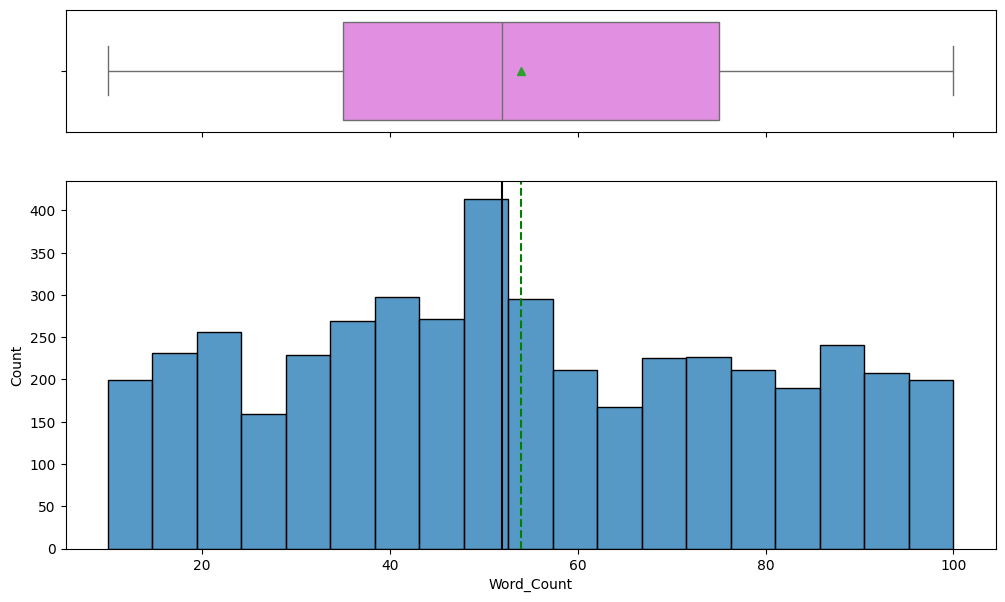

In [9]:
histogram_boxplot(df, 'Word_Count');

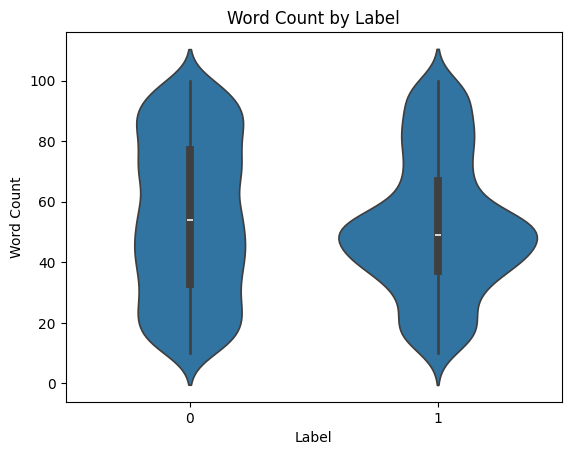

In [10]:
sns.violinplot(x="Label", y="Word_Count", data=df)
plt.title("Word Count by Label")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.show()

<b>Observations:</b>
<ul>
    <li>Pronounced difference in distributions of number of sentences, depending on label.</li>
    <li>Real news tends to have a more uniform distribution of word count.</li>
    <li>Fake news tends to have a relatively uniform distribution of word count, with a significant cluster being within the range of 40-60.</li>
</ul>

### Number of Sentences

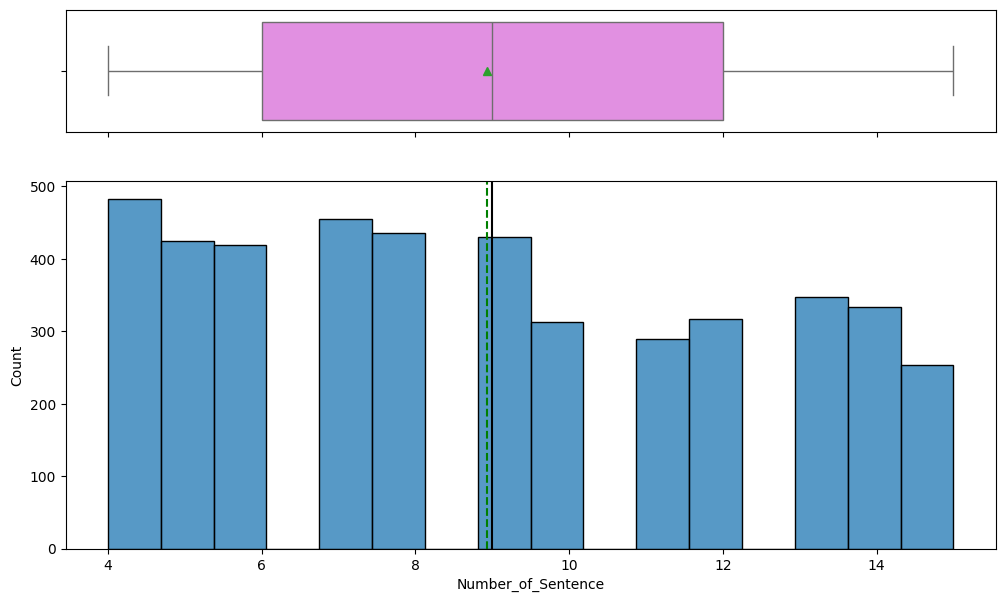

In [11]:
histogram_boxplot(df, 'Number_of_Sentence');

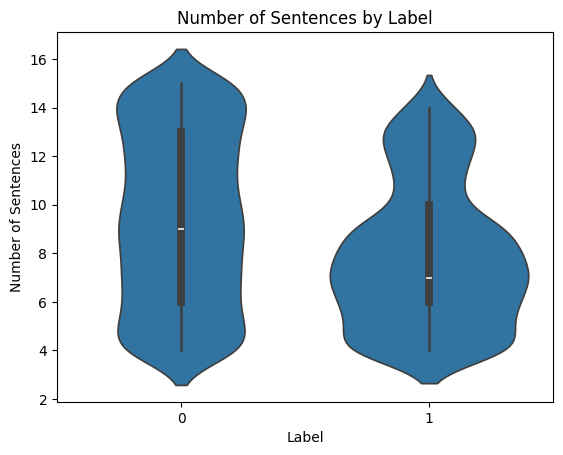

In [12]:
sns.violinplot(x="Label", y="Number_of_Sentence", data=df)
plt.title("Number of Sentences by Label")
plt.xlabel("Label")
plt.ylabel("Number of Sentences")
plt.show()

<b>Observations:</b>
<ul>
    <li>Pronounced difference in distributions of number of sentences, depending on label.</li>
    <li>Real news tends to have a more uniform distribution of sentences.</li>
    <li>Fake news tends to have a more right-skewed distribution of sentences.</li>
</ul>

### Unique Words

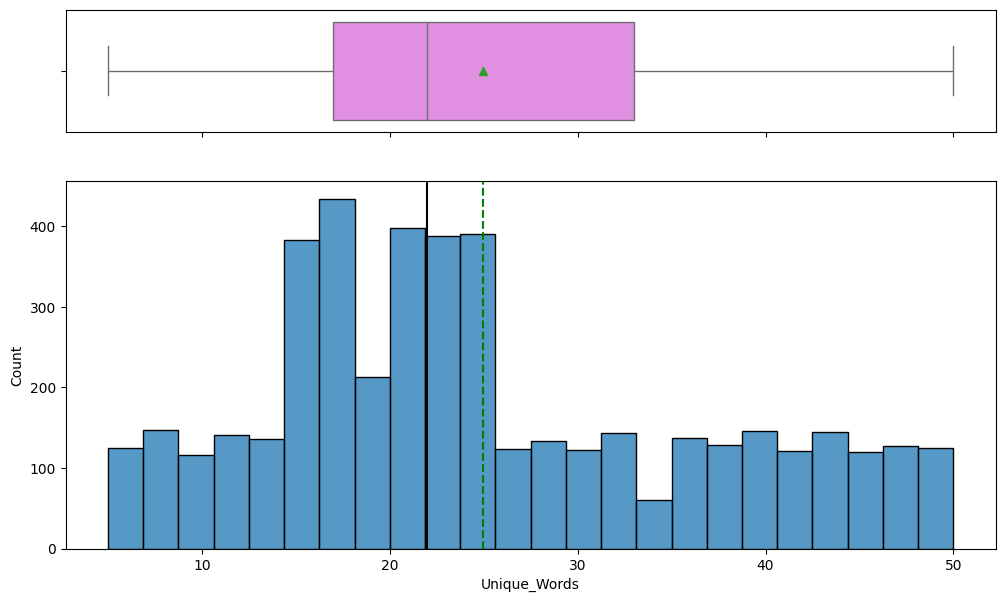

In [13]:
histogram_boxplot(df, 'Unique_Words');

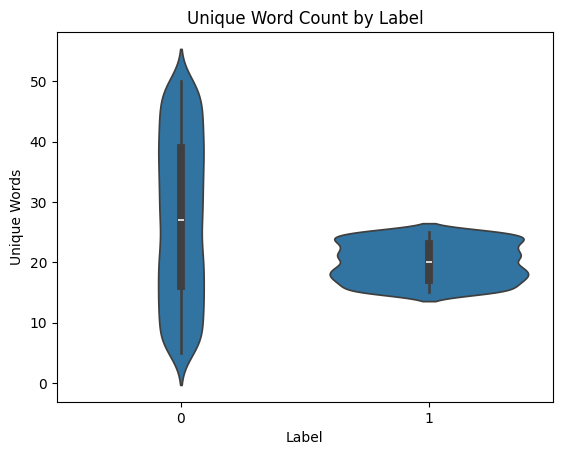

In [14]:
sns.violinplot(x="Label", y="Unique_Words", data=df)
plt.title("Unique Word Count by Label")
plt.xlabel("Label")
plt.ylabel("Unique Words")
plt.show()

<b>Observations:</b>
<ul>
    <li>Extremely large difference in distributions, depending on label.</li>
    <li>Much wider distribution of unique word count for real news</li>
    <li>Very close/clustered distribution of unique word count for fake news</li>
</ul>

### Average Word Length

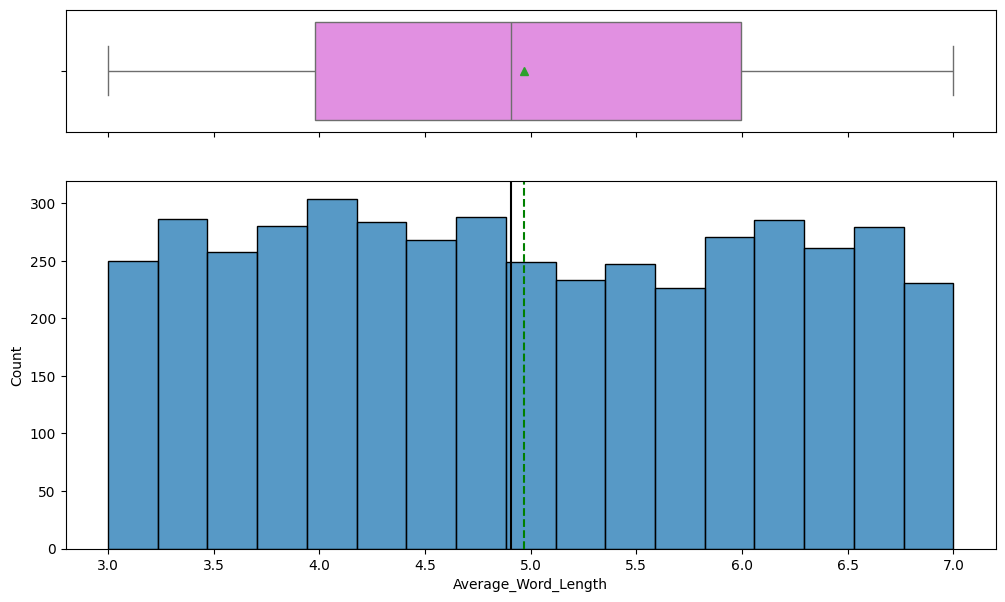

In [15]:
histogram_boxplot(df, 'Average_Word_Length');

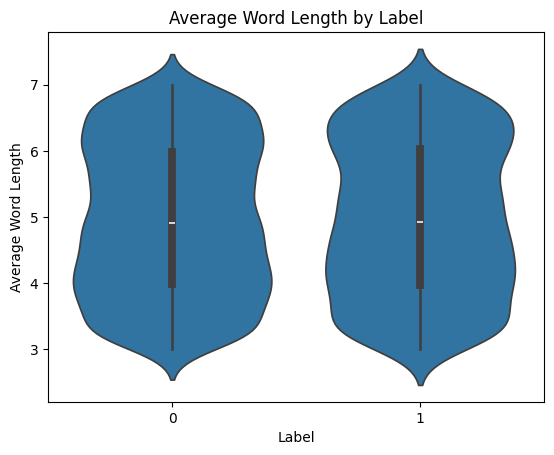

In [16]:
# Create a violin plot
sns.violinplot(x="Label", y="Average_Word_Length", data=df)
plt.title("Average Word Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Word Length")
plt.show()

<b>Observations:</b>
<ul>
    <li>The width of the plot represents the density of data at different average word lengths. A wider portion indicates higher density, while narrower portions indicate lower density.</li>
    <li>The violin plot shows variations in density within certain ranges of average word lengths. These variations might indicate specific patterns or trends in writing style for both real and fake news articles</li>
</ul>

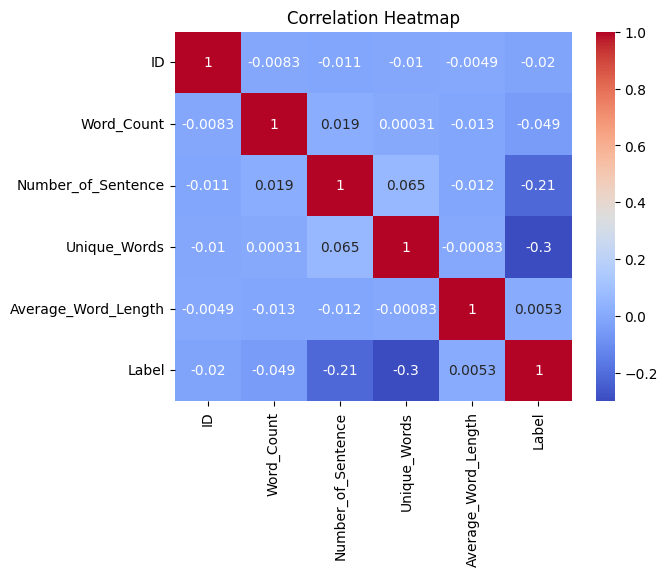

In [17]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insights from the Correlation Heatmap**

- The correlation between "Word_Count" and the "Label" is approximately -0.0489. This indicates a very weak negative correlation between the word count of an article and whether it is real news (Label 0) or fake news (Label 1).

- **The correlation between "Number_of_Sentence" and the "Label" is approximately -0.21.** This moderate negative correlation suggests that there's a more noticeable relationship between the number of sentences in an article and whether it's a fake news article or not.

- **The correlation between "Unique_Words" and the "Label" is approximately -0.3.** This moderate negative correlation suggests that fake news articles tend to use fewer unique words compared to real news articles. This could be an interesting feature for classification, as it indicates differences in vocabulary richness between the two categories.

- Most of the correlations between the other pairs of variables are close to zero or very low. This indicates a lack of strong linear relationships between these pairs of variables.

## **Model Building**

Insert documentation that describes the split ratio and why training and test datasets.  Document the RandomForestClassifier class and what the hyperparameter options area.  Make sure to describe what the fit process is for and conclude with an evaluation using the metrics accuracy, precision, recall and F1 score.


In [18]:
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score

In [19]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def saveTestResults(model, pred, target, data, modelName, isTrain: bool):

    # predicting using the independent variables
    precision = precision_score(target, pred)
    recall = recall_score(target, pred)
    f1 = f1_score(target, pred)
    accuracy = accuracy_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Accuracy": accuracy
        },
        index=[0],
    )
    
    # Storing results 
    if isTrain == False:
        data['Model'].append(modelName)
        data['Precision'].append(precision)
        data['Recall'].append(recall)
        data['F1 Score'].append(f1)
        data['Accuracy'].append(accuracy)    

    return df_perf

In [20]:
resultsDict = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}

In [21]:
def getBestThreshold(model, pred, target, data, modelName):
    '''Function to compute optimal prediction threshold for given model'''
    
    # Get predicted probabilities for the positive class
    baseProbs = model.predict_proba(pred)[:, 1]
    
    threshold = 0.3
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        customPred = (baseProbs >= threshold).astype(int)

        res = saveTestResults(model, customPred, target, data, modelName, isTrain=True)
        results['Precision'].append((res['Precision'][0], threshold))
        results['Recall'].append((res['Recall'][0], threshold))
        results['F1 Score'].append((res['F1 Score'][0], threshold))
        results['Accuracy'].append((res['Accuracy'][0], threshold))

        if threshold >= 0.99:
            break
        else:
            threshold = round(threshold + 0.01, 2)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

##### Training/Test Splits

- Generally, there should be somewhere between a 70/30 - 80/20 split between training and test data from the dataset. Since this particular dataset is on the smaller side, it is likely beneficial to leave the split at 70/30, since we need enough instances in the test set to obtain reliable performance estimates and assess the model's generalization ability.

### Random Forest

In [22]:
# Separate features (X) and target variable (y)
X = df.drop(['Label',"ID"], axis=1)
y = df['Label']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

In [23]:
# Train the RandomForest model
rf_model = RandomForestClassifier(n_estimators =150,max_depth =5,random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=150, random_state=42)

In [24]:
# Setting predictions for training set
trainPred = rf_model.predict(X_train)
trainResults = saveTestResults(rf_model, trainPred, y_train, resultsDict, "RandomForest", isTrain=True)
trainResults

,Precision,Recall,F1 Score,Accuracy
0,0.777526,1.0,0.874841,0.906349


In [25]:
testPred = rf_model.predict(X_test)
testResults = saveTestResults(rf_model, testPred, y_test, resultsDict, "RandomForest", isTrain=False)
testResults

,Precision,Recall,F1 Score,Accuracy
0,0.753333,1.0,0.859316,0.89037


- Initially, the test set performs quite well, with minor hiccups in precision. Let's see if we can optimize the model further, by adjusting the prediction threshold.

#### Prediction Threshold

In [26]:
# Getting best prediction threshold for test set
warnings.filterwarnings('ignore')
optimized = getBestThreshold(rf_model, X_test, y_test, resultsDict, "RandomForest")
warnings.filterwarnings('default')
optimized

{'Precision': (1.0, 0.78),
 'Recall': (1.0, 0.62),
 'F1 Score': (0.8675623800383877, 0.62),
 'Accuracy': (0.8977777777777778, 0.62)}

- Overall, the best threshold appears to be 0.62, as it is optimal for three out of four metrics. However, this may cause the base precision value to drop.

In [27]:
baseProb = rf_model.predict_proba(X_test)[:, 1]
threshold = 0.62
customPred = (baseProb >= threshold).astype(int)

threshResults = saveTestResults(rf_model, customPred, y_test, resultsDict, "RandomForest0.62", isTrain=False)
threshResults

,Precision,Recall,F1 Score,Accuracy
0,0.766102,1.0,0.867562,0.897778


- Marginal improvements in every metric, excluding recall. Just for fun, let's try with the optimal threshold for precision.

#### Randomized Search Optimization

Initially, we're going to use randomized search to get the longer-to-optimize parameters out of the way, so we can focus on the others.

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

params = {
    'n_estimators': randint(100, 1000),  # Number of trees in the forest
    'max_depth': randint(5, 50),          # Maximum depth of each tree
    'min_samples_split': randint(2, 20),  # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 20),   # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'bootstrap': [True, False]            # Whether bootstrap samples are used when building trees
}

In [29]:
rf_model = RandomForestClassifier()

search = RandomizedSearchCV(estimator=rf_model, param_distributions=params, n_iter=100,
                           random_state=42)
warnings.filterwarnings('ignore')
search.fit(X_train, y_train)
warnings.filterwarnings('default')

print("Best Params: ", search.best_params_)

Best Params:  {'bootstrap': True, 'max_depth': 13, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 18, 'n_estimators': 198}


In [30]:
optimizedRF = search.best_estimator_

pred = optimizedRF.predict(X_test)

randomizedResults = saveTestResults(optimizedRF, pred, y_test, resultsDict, "RandomForestRS", isTrain=False)
randomizedResults

,Precision,Recall,F1 Score,Accuracy
0,0.768707,1.0,0.869231,0.899259


- Considerable progress in precision, and marginal progress in other metrics.

#### Class Weight

In [31]:
best_params = search.best_params_
searchRF_model = RandomForestClassifier(**best_params)

searchRF_model.set_params(class_weight='balanced')
searchRF_model.fit(X_train, y_train)

pred = searchRF_model.predict(X_test)

weightResults = saveTestResults(searchRF_model, pred, y_test, resultsDict, "RandomForestRS", isTrain=True)
weightResults

,Precision,Recall,F1 Score,Accuracy
0,0.767402,1.0,0.868396,0.898519


- Using 'balanced' set us back, so let's try using custom weights within a range from 0.1-2

In [32]:
custom_weights = {0: 0.1, 1: 0.1}

results = {
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}
warnings.filterwarnings('ignore')
for i in range(20):
    custom_weights[1] = 0.1
    for i in range(20):
        searchRF_model = RandomForestClassifier(**best_params)
        searchRF_model.set_params(class_weight=custom_weights)
        searchRF_model.fit(X_train, y_train)
        
        pred = searchRF_model.predict(X_test)
        
        res = saveTestResults(searchRF_model, pred, y_test, resultsDict, "RandomForestRS", isTrain=True)
        results['Precision'].append((res['Precision'][0], (custom_weights[0], custom_weights[1])))
        results['Recall'].append((res['Recall'][0], (custom_weights[0], custom_weights[1])))
        results['F1 Score'].append((res['F1 Score'][0], (custom_weights[0], custom_weights[1])))
        results['Accuracy'].append((res['Accuracy'][0], (custom_weights[0], custom_weights[1])))

        custom_weights[1] = round(custom_weights[1] + 0.1, 1)
    custom_weights[0] = round(custom_weights[0] + 0.1, 1)

for key, value in results.items():
    results[key] = max(value)
warnings.filterwarnings('default')
results

{'Precision': (0.9393939393939394, (2.0, 0.1)),
 'Recall': (1.0, (2.0, 2.0)),
 'F1 Score': (0.8731848983543078, (1.0, 0.9)),
 'Accuracy': (0.902962962962963, (1.9, 1.3))}

- Based on this, it seems clear that 1.9, 1.7 are the optimal weights for this model.

#### Further Threshold Optimization

Since we're effectively using a different model than we were last time we optimized the prediction threshold, it is likely beneficial to do this again with the new parameters, just to make sure we aren't missing something.

In [33]:
optimizedRF_model = RandomForestClassifier(**best_params)
optimizedRF_model.set_params(class_weight={0: 1.9, 1: 1.7})
optimizedRF_model.fit(X_train, y_train)

warnings.filterwarnings('ignore')
optimized2 = getBestThreshold(optimizedRF_model, X_test, y_test, resultsDict, "RandomForest")
warnings.filterwarnings('default')
optimized2

{'Precision': (1.0, 0.97),
 'Recall': (1.0, 0.51),
 'F1 Score': (0.8737864077669902, 0.53),
 'Accuracy': (0.9037037037037037, 0.56)}

- Tweaking the threshold more, we were able to squeeze another 0.7% accuracy out of the model, let's see the full results, using the optimal threshold.

In [34]:
baseProb = optimizedRF_model.predict_proba(X_test)[:, 1]
threshold = 0.53
customPred = (baseProb >= threshold).astype(int)

threshResults2 = saveTestResults(optimizedRF_model, customPred, y_test, resultsDict, "RandomForestRS0.53", isTrain=False)
threshResults2

,Precision,Recall,F1 Score,Accuracy
0,0.778547,0.995575,0.873786,0.903704


#### Best RF Scores

In [35]:
# Making the DF more visually appealing
styles = [
    dict(selector="th", props=[("font-size", "150%"), ("text-align", "left")]),
    dict(selector="td", props=[("font-size", "120%"), ("text-align", "center")])
]

# Format results into a table
styled = threshResults2.style.set_table_styles(styles)
styled

,Precision,Recall,F1 Score,Accuracy
0,0.778547,0.995575,0.873786,0.903704


### Support Vector Machines

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
# SVM needs scaled data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [37]:
svm_classifier = SVC(random_state=42)

svm_classifier.fit(X_train_scaled, y_train)

y_pred = svm_classifier.predict(X_test_scaled)

In [38]:
svcTestResults = saveTestResults(svm_classifier, y_pred, y_test, resultsDict, "SVC", isTrain=False)
svcTestResults

,Precision,Recall,F1 Score,Accuracy
0,0.715909,0.975664,0.825843,0.862222


- This performance is rather lackluster, especially when looking at precision. Since SVM typically has a strong precision score, it is abnormal for it to be lower than that of Random Forest.
- Because of this, we need to do some tweaking.

#### Scaling Gamma

In [39]:
def scaledGamma(kernel, target, data):
    '''Function to compute relative optimal gamma value for SVM'''
    
    gammaVar = 0.0001
    decimals = 4
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        if kernel == "poly":
            svm_classifier = SVC(kernel=kernel, gamma=gammaVar, random_state=42, degree=3)
        else:
            svm_classifier = SVC(kernel=kernel, gamma=gammaVar, random_state=42)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)
        
        res = saveTestResults(svm_classifier, this_pred, target, data, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], gammaVar))
        results['Recall'].append((res['Recall'][0], gammaVar))
        results['F1 Score'].append((res['F1 Score'][0], gammaVar))
        results['Accuracy'].append((res['Accuracy'][0], gammaVar))

        if gammaVar >= 1:
            break
        else:
            if decimals > 2:
                decimals = decimals - 1
            gammaVar = round(gammaVar * 10, decimals)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [40]:
def getBestGamma(target, lowerBound, upperBound):
    '''Function to compute relative optimal gamma value for SVM'''
    
    gammaVar = lowerBound
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        svm_classifier = SVC(kernel='rbf', gamma=gammaVar, random_state=42)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)
        
        res = saveTestResults(svm_classifier, this_pred, target, resultsDict, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], gammaVar))
        results['Recall'].append((res['Recall'][0], gammaVar))
        results['F1 Score'].append((res['F1 Score'][0], gammaVar))
        results['Accuracy'].append((res['Accuracy'][0], gammaVar))

        if gammaVar >= upperBound:
            break
        else:
            gammaVar = round(gammaVar + lowerBound, 2)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [41]:
bestGamma = scaledGamma('rbf', y_test, resultsDict)

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [42]:
bestGamma

{'Precision': (0.7372013651877133, 1.0),
 'Recall': (0.9601769911504425, 0.1),
 'F1 Score': (0.8323699421965318, 1.0),
 'Accuracy': (0.8711111111111111, 1.0)}

- On its own, changing the gamma netted us minor improvements in every metric, depending on the value used (we would probably move forward with a value of 1).
- Still, we could probably do better, so let's try again, this time finding the best gamma value, depending on the kernel used.

#### Kernel

In [43]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
warnings.filterwarnings('ignore')
kernResults = {
    "Kernel": [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}
# For each kernel, add the highest recorded score for each metric
# along with its coinciding gamma value
for kernel in kernels:
    this_output = scaledGamma(kernel, y_test, resultsDict)
    kernResults['Kernel'].append(kernel)
    kernResults['Precision'].append(this_output['Precision'])
    kernResults['Recall'].append(this_output['Recall'])
    kernResults['F1 Score'].append(this_output['F1 Score'])
    kernResults['Accuracy'].append(this_output['Accuracy'])
    
warnings.filterwarnings('default')

In [44]:
kernResultsDF = pd.DataFrame(kernResults)

In [45]:
kernResultsDF

,Kernel,Precision,Recall,F1 Score,Accuracy
0,linear,"(0.0, 1.0)","(0.0, 1.0)","(0.0, 1.0)","(0.6651851851851852, 1.0)"
1,rbf,"(0.7372013651877133, 1.0)","(0.9601769911504425, 0.1)","(0.8323699421965318, 1.0)","(0.8711111111111111, 1.0)"
2,poly,"(0.5205479452054794, 1.0)","(0.084070796460177, 1.0)","(0.14476190476190476, 1.0)","(0.6674074074074074, 1.0)"
3,sigmoid,"(0.37202380952380953, 0.1)","(0.3230088495575221, 1.0)","(0.3219404630650496, 1.0)","(0.6651851851851852, 0.01)"


- Based on this, it seems obvious that a gamma bewteen 0.1-1 is going to be the best going forward, along with the rbf kernel.
- Let's further refine the gamma, and see if we can improve the score even more.

In [46]:
warnings.filterwarnings('ignore')
bestGammaSVM = getBestGamma(y_test, 0.1, 1)
warnings.filterwarnings('default')

In [47]:
bestGammaSVM

{'Precision': (0.7372013651877133, 1.0),
 'Recall': (0.9756637168141593, 0.3),
 'F1 Score': (0.8333333333333334, 0.7),
 'Accuracy': (0.8711111111111111, 1.0)}

- 1.0 appears to be optimal, given only a very slight increase in F1 and recall, with their respective optimal gamma values.
- Let's try a range of 1-10, just in case.

In [48]:
warnings.filterwarnings('ignore')
bestGammaSVM2 = getBestGamma(y_test, 1, 10)
warnings.filterwarnings('default')

In [49]:
bestGammaSVM2

{'Precision': (0.7706855791962175, 10),
 'Recall': (0.9557522123893806, 1),
 'F1 Score': (0.8323699421965318, 1),
 'Accuracy': (0.8711111111111111, 1)}

Based on this, I think it's safe to say that 'rfb' with a gamma of '1' is optimal.

#### Regularization

In [50]:
def scaleReg(target, lowerBound, upperBound):
    '''Function to compute relative optimal C value for SVM'''
    
    cVar = lowerBound
    decimals = 4
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        svm_classifier = SVC(kernel='rbf', gamma=1, random_state=42, C=cVar)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)
        
        res = saveTestResults(svm_classifier, this_pred, target, resultsDict, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], cVar))
        results['Recall'].append((res['Recall'][0], cVar))
        results['F1 Score'].append((res['F1 Score'][0], cVar))
        results['Accuracy'].append((res['Accuracy'][0], cVar))

        if cVar >= upperBound:
            break
        else:
            if decimals > 2:
                decimals = decimals - 1
            cVar = round(cVar * 10, decimals)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

First, we'll check the optimal range, using a broad parameter:

In [51]:
bestReg = scaleReg(y_test, 0.0001, 1000)

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [52]:
bestReg

{'Precision': (0.7422037422037422, 1000.0),
 'Recall': (0.9557522123893806, 1.0),
 'F1 Score': (0.8323699421965318, 1.0),
 'Accuracy': (0.8711111111111111, 1.0)}

The optimal value for C appears to be around 1, so let's check between the ranges of 0.1-1 and 1-10

In [53]:
def getBestReg(target, lowerBound, upperBound):
    '''Function to compute relative optimal C value for SVM'''
    
    cVar = lowerBound
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        svm_classifier = SVC(kernel='rbf', gamma=1, random_state=42, C=cVar)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)
        
        res = saveTestResults(svm_classifier, this_pred, target, resultsDict, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], cVar))
        results['Recall'].append((res['Recall'][0], cVar))
        results['F1 Score'].append((res['F1 Score'][0], cVar))
        results['Accuracy'].append((res['Accuracy'][0], cVar))

        if cVar >= upperBound:
            break
        else:
            cVar = round(cVar + lowerBound, 2)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [54]:
bestReg1 = getBestReg(y_test, 0.1, 1)
bestReg1

{'Precision': (0.7372013651877133, 1.0),
 'Recall': (0.9601769911504425, 0.4),
 'F1 Score': (0.8330134357005758, 0.4),
 'Accuracy': (0.8711111111111111, 1.0)}

In [55]:
bestReg2 = getBestReg(y_test, 1, 10)
bestReg2

{'Precision': (0.7417677642980935, 2),
 'Recall': (0.9557522123893806, 1),
 'F1 Score': (0.8323699421965318, 1),
 'Accuracy': (0.8718518518518519, 2)}

It seems like 0.4 is the best performer, but seeing as precision is our worst metric, by far, and it is fairly improved by a regularization of '2', it would likely be best to stick with that.

In [56]:
svm_classifier = SVC(kernel='rbf', gamma=1, random_state=42, C=2)

svm_classifier.fit(X_train_scaled, y_train)
this_pred = svm_classifier.predict(X_test_scaled)

regOutput = saveTestResults(svm_classifier, this_pred, y_test, resultsDict, "SVC", isTrain=True)
regOutput

,Precision,Recall,F1 Score,Accuracy
0,0.741768,0.946903,0.831876,0.871852


- Since the precision isn't too drastically altered by the C value of 0.4, we will move forward with using it.

#### Class Weights

The purpose of this parameter is to adjust class weights, depending on their frequency in the dataset (which helps with imbalanced data). This is useful for our dataset, since there are many more true news articles than there are fake ones. 

In [57]:
svm_classifier = SVC(kernel='rbf', gamma=1, random_state=42, C=2, class_weight='balanced')

svm_classifier.fit(X_train_scaled, y_train)
this_pred = svm_classifier.predict(X_test_scaled)

weightOutput = saveTestResults(svm_classifier, this_pred, y_test, resultsDict, "SVC", isTrain=True)
weightOutput

,Precision,Recall,F1 Score,Accuracy
0,0.725649,0.988938,0.837079,0.871111


- Initial results with the 'balanced' value for the class_weight parameter are promising, but sadly push our already struggling precision in the wrong direction. Let's try custom weights through a range of 0.1-2.

In [58]:
custom_weights = {0: 0.1, 1: 0.1}

results = {
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}
warnings.filterwarnings('ignore')
for i in range(20):
    custom_weights[1] = 0.1
    for i in range(20):
        svm_classifier = SVC(kernel='rbf', gamma=1, random_state=42, C=2, class_weight=custom_weights)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)

        res = saveTestResults(svm_classifier, this_pred, y_test, resultsDict, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], (custom_weights[0], custom_weights[1])))
        results['Recall'].append((res['Recall'][0], (custom_weights[0], custom_weights[1])))
        results['F1 Score'].append((res['F1 Score'][0], (custom_weights[0], custom_weights[1])))
        results['Accuracy'].append((res['Accuracy'][0], (custom_weights[0], custom_weights[1])))

        custom_weights[1] = round(custom_weights[1] + 0.1, 1)
    custom_weights[0] = round(custom_weights[0] + 0.1, 1)

for key, value in results.items():
    results[key] = max(value)
warnings.filterwarnings('default')
results

{'Precision': (1.0, (2.0, 0.3)),
 'Recall': (1.0, (0.6, 2.0)),
 'F1 Score': (0.8404966571155683, (1.3, 1.8)),
 'Accuracy': (0.8762962962962964, (1.3, 1.8))}

- Unsurprisingly, both precision and recall are easily able to reach scores of '1', with heavy weights.
- 1.3, 1.8 weights are clearly optimal, for both f1 and accuracy.

In [59]:
custom_weights = {0: 1.3, 1: 1.8}
svm_classifier = SVC(kernel='rbf', gamma=1, random_state=42, C=2, class_weight=custom_weights)

svm_classifier.fit(X_train_scaled, y_train)
this_pred = svm_classifier.predict(X_test_scaled)

weightOutput = saveTestResults(svm_classifier, this_pred, y_test, resultsDict, "Optimized SVC", isTrain=False)
weightOutput

,Precision,Recall,F1 Score,Accuracy
0,0.739496,0.973451,0.840497,0.876296


In [62]:
from scipy.stats import uniform

param_dist = {
    'C': uniform(loc=0, scale=10),           # Regularization parameter
    'kernel': ['linear', 'poly', 'rbf'],    # Kernel type
    'gamma': ['scale', 'auto'],              # Kernel coefficient for 'rbf' and 'poly'
    'degree': randint(2, 5)                  # Degree of the polynomial kernel
}

# Create an SVC classifier
svc_clf = SVC()

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=svc_clf, param_distributions=param_dist, n_iter=100, cv=5, random_state=42)

# Perform the randomized search
random_search.fit(X_train, y_train)

# Print the best parameters found
print("Best Parameters:", random_search.best_params_)

# Evaluate the best model on the test set
best_model = random_search.best_estimator_
pred = best_model.predict(X_test_scaled)

testResults = saveTestResults(best_model, pred, y_test, resultsDict, "SVCSearch", isTrain=True)

KeyboardInterrupt: 

#### Final SVM Scores

In [60]:
styles = [
    dict(selector="th", props=[("font-size", "150%"), ("text-align", "left")]),
    dict(selector="td", props=[("font-size", "120%"), ("text-align", "center")])
]

# Format results into a table
styled = weightOutput.style.set_table_styles(styles)
styled

,Precision,Recall,F1 Score,Accuracy
0,0.739496,0.973451,0.840497,0.876296


## **Performance**

In [61]:
fullResults = pd.DataFrame(resultsDict)

cmap_reversed = sns.color_palette("coolwarm", as_cmap=True)
cmap_reversed = cmap_reversed.reversed()

# Format results into a table
styled_fullResults = fullResults.style.background_gradient(cmap=cmap_reversed)
styled_fullResults

,Model,Precision,Recall,F1 Score,Accuracy
0,RandomForest,0.753333,1.000000,0.859316,0.890370
1,RandomForest0.62,0.766102,1.000000,0.867562,0.897778
2,RandomForestRS,0.768707,1.000000,0.869231,0.899259
3,RandomForestRS0.53,0.778547,0.995575,0.873786,0.903704
4,SVC,0.715909,0.975664,0.825843,0.862222
5,Optimized SVC,0.739496,0.973451,0.840497,0.876296


## **Conclusions**

- Even after exhaustively tuning hyperparameters for the SVM Classifier, it couldn't hold a candle to even the base random forest model.
- The largest difference in performance from the random forest model came from tuning the decision threshold.
- Even in precision, which is typically SVM's specialty, random forest is far better.